#개요

In [1]:
import pandas as pd
import numpy as np
import os
from google.colab import drive
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data_path = "/content/drive/My Drive/Colab Notebooks/IBA_REG"
data_name = os.listdir(data_path)

In [4]:
data_name

['train.csv',
 'test.csv',
 'brand_model.csv',
 'IBA_reg_comp_BASELINE.ipynb',
 'sample_submission.csv',
 'xgboost_submission.csv']

In [5]:
train = pd.read_csv(data_path + '/' + data_name[0])
test = pd.read_csv(data_path + '/' + data_name[1])
train.head()

,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
0,hyundi,I30,2015,Automatic,18078.0,Diesel,20.0,67.3,1.6,8995
1,merc,A Class,2018,Automatic,4350.0,Diesel,145.0,68.9,2.1,19499
2,skoda,Octavia,2019,Manual,9373.0,Diesel,NaN,67.3,1.6,14395
3,toyota,Verso,2011,Manual,74488.0,Petrol,200.0,41.5,1.6,5899
4,merc,C Class,2019,Automatic,608.0,Petrol,145.0,42.2,2.0,26949


In [6]:
# 테스트 데이터 결측치 확인
missing_values_test = test.isnull().sum()
print("테스트 데이터 결측치 개수:")
display(missing_values_test)

테스트 데이터 결측치 개수:


,0
id,0
brand,0
model,0
year,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58627 entries, 0 to 58626
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         58627 non-null  object 
 1   model         58627 non-null  object 
 2   year          58627 non-null  int64  
 3   transmission  58627 non-null  object 
 4   mileage       57849 non-null  float64
 5   fuelType      58627 non-null  object 
 6   tax           53515 non-null  float64
 7   mpg           53035 non-null  float64
 8   engineSize    58627 non-null  float64
 9   price         58627 non-null  int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 4.5+ MB


# mileage 결측치 대체


In [8]:
# 연도와 모델별 'mileage' 중앙값 계산
mileage_median_by_year_model = train.groupby(['year', 'model'])['mileage'].transform('median')

# 계산된 그룹별 중앙값으로 'mileage' 결측값 채우기
train['mileage'] = train['mileage'].fillna(mileage_median_by_year_model)

# 남아있는 결측값을 위해 연도별 'mileage' 중앙값 계산
mileage_median_by_year = train.groupby('year')['mileage'].transform('median')

# 남아있는 'mileage' 결측값을 계산된 연도별 중앙값으로 채우기
train['mileage'] = train['mileage'].fillna(mileage_median_by_year)

# 여전히 남아있는 결측값은 전체 중앙값으로 채우기 (폴백)
train['mileage'] = train['mileage'].fillna(train['mileage'].median())

# 'mileage'에 더 이상 결측값이 없는지 확인
print("결측값 대체 후 'mileage'의 결측값 개수:", train['mileage'].isnull().sum())

결측값 대체 후 'mileage'의 결측값 개수: 0


# mpg 결측치 대체

In [9]:
# 연도, 모델, 연료 타입별 'mpg' 중앙값 계산
mpg_median_by_year_model_fuel = train.groupby(['year', 'model', 'fuelType'])['mpg'].transform('median')

# 계산된 그룹별 중앙값으로 'mpg' 결측값 채우기
train['mpg'] = train['mpg'].fillna(mpg_median_by_year_model_fuel)

# 남아있는 결측값을 위해 연도와 모델별 'mpg' 중앙값 계산 (두 번째 대체)
mpg_median_by_year_model = train.groupby(['year', 'model'])['mpg'].transform('median')
train['mpg'] = train['mpg'].fillna(mpg_median_by_year_model)

# 남아있는 결측값을 위해 모델별 'mpg' 중앙값 계산 (세 번째 대체)
mpg_median_by_model = train.groupby('model')['mpg'].transform('median')
train['mpg'] = train['mpg'].fillna(mpg_median_by_model)

# 원래 'mpg'가 결측치였던 행의 인덱스를 저장
missing_mpg_indices_before = train[train['mpg'].isnull()].index

# 남은 결측값(들)을 35.3으로 채우기
train['mpg'] = train['mpg'].fillna(35.3)

# 'mpg'에 더 이상 결측값이 없는지 확인
print("결측값 대체 후 'mpg'의 결측값 개수:", train['mpg'].isnull().sum())

# 35.3으로 채워진 행(들) 보여주기
print("\n35.3으로 채워진 행 정보:")
display(train.loc[missing_mpg_indices_before])

결측값 대체 후 'mpg'의 결측값 개수: 0

35.3으로 채워진 행 정보:


,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
48190,ford,Streetka,2005,Manual,63000.0,Petrol,270.0,35.3,1.6,1999


In [10]:
# 연도, 모델, 연료 타입별 'tax' 중앙값 계산
tax_median_by_year_model_fuel = train.groupby(['year', 'model', 'fuelType'])['tax'].transform('median')

# 계산된 그룹별 중앙값으로 'tax' 결측값 채우기
train['tax'] = train['tax'].fillna(tax_median_by_year_model_fuel)

# 남아있는 결측값을 위해 연도와 모델별 'tax' 중앙값 계산 (두 번째 대체)
tax_median_by_year_model = train.groupby(['year', 'model'])['tax'].transform('median')
train['tax'] = train['tax'].fillna(tax_median_by_year_model)

# 남아있는 결측값을 위해 모델별 'tax' 중앙값 계산 (세 번째 대체)
tax_median_by_model = train.groupby('model')['tax'].transform('median')
train['tax'] = train['tax'].fillna(tax_median_by_model)

# 'tax'에 결측값이 남아 있는지 확인
print("결측값 대체 후 'tax'의 결측값 개수:", train['tax'].isnull().sum())

# 남아있는 결측값이 있다면 해당 행 보여주기
if train['tax'].isnull().sum() > 0:
    print("\n남아있는 'tax' 결측치 행 정보:")
    display(train[train['tax'].isnull()])

결측값 대체 후 'tax'의 결측값 개수: 0


# transmission other 처리

In [11]:
#그냥 최빈값 뭔지 확인하는 코드

# 1) 모델별로 other 제외한 변속기 최빈값 계산
mode_trans = (
    train[train['transmission'] != 'Other']
    .groupby(['brand', 'model'])['transmission']
    .agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else None)
    .reset_index()
    .rename(columns={'transmission': 'suggested_transmission'})
)

# 2) transmission = Other 인 행만 필터
other_rows = train[train['transmission'] == 'Other'][['brand', 'model', 'transmission']].copy()

# 3) other 목록에 최빈 변속기 추천값 merge
result = other_rows.merge(mode_trans, on=['brand', 'model'], how='left')

result

,brand,model,transmission,suggested_transmission
0,hyundi,Ioniq,Other,Automatic
1,hyundi,Tucson,Other,Manual
2,toyota,Yaris,Other,Manual
3,merc,GLA Class,Other,Semi-Auto
4,vauxhall,Mokka,Other,Manual
5,vauxhall,Mokka,Other,Manual


In [12]:
#변환코드

import pandas as pd


# 모델별로 other 제외한 변속기 최빈값 계산
mode_trans = (
    train[train['transmission'] != 'Other']
    .groupby(['brand', 'model'])['transmission']
    .agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else None)
    .reset_index()
    .rename(columns={'transmission': 'suggested_transmission'})
)

# Check if 'suggested_transmission' column already exists and drop if necessary before merging
if 'suggested_transmission' in train.columns:
    train = train.drop('suggested_transmission', axis=1)

train = train.merge(mode_trans, on=['brand', 'model'], how='left')

# Other인 경우에만 suggested 값으로 치환
train['transmission'] = train.apply(
    lambda row: row['suggested_transmission'] if row['transmission'] == 'Other' and pd.notnull(row['suggested_transmission'])
    else row['transmission'],
    axis=1
)

# 사용 후 suggested_transmission 컬럼 삭제 (체크 후 삭제)
if 'suggested_transmission' in train.columns:
    train = train.drop('suggested_transmission', axis=1)


# 남아있는 'transmission' = 'Other'인 행 확인 및 제거
other_transmission_rows = train[train['transmission'] == 'Other']

if not other_transmission_rows.empty:
    indices_to_remove = other_transmission_rows.index
    train = train.drop(indices_to_remove).reset_index(drop=True)
    print(f"Info: {len(indices_to_remove)} rows with 'transmission' = 'Other' were removed.")
else:
    print("Info: No 'transmission' = 'Other' rows remained after imputation.")

# 삭제 확인 (선택 사항)
print("'transmission'이 'Other'인 행 삭제 후 train 데이터의 행 수:", len(train))
print("train 데이터에서 'transmission'이 'Other'인 행 확인:", train[train['transmission'] == 'Other'].shape[0])

Info: No 'transmission' = 'Other' rows remained after imputation.
'transmission'이 'Other'인 행 삭제 후 train 데이터의 행 수: 58627
train 데이터에서 'transmission'이 'Other'인 행 확인: 0


In [13]:
# 변속기 변수에 있는 other class 바꾼 결과
result


,brand,model,transmission,suggested_transmission
0,hyundi,Ioniq,Other,Automatic
1,hyundi,Tucson,Other,Manual
2,toyota,Yaris,Other,Manual
3,merc,GLA Class,Other,Semi-Auto
4,vauxhall,Mokka,Other,Manual
5,vauxhall,Mokka,Other,Manual


# fuel type other 처리

In [14]:
# 'mpg' 열을 숫자로 변환 (오류 발생 시 결측치로 처리)
train['mpg'] = pd.to_numeric(train['mpg'], errors='coerce')

# 'fuelType'이 'Other'이고 'mpg'가 100 이상인 행 조건 정의
# 'mpg'가 결측치인 경우는 조건에서 제외됩니다.
condition_replace_other_to_hybrid = (train['fuelType'] == 'Other') & (train['mpg'] >= 100)

# 조건에 해당하는 행의 'fuelType' 값을 'Hybrid'로 대체
rows_changed_count = train.loc[condition_replace_other_to_hybrid, 'fuelType'].shape[0]
train.loc[condition_replace_other_to_hybrid, 'fuelType'] = 'Hybrid'

# 변경된 행 수 확인 (선택 사항)
print(f"'fuelType'이 'Other'이고 'mpg' >= 100인 행 중 {rows_changed_count}개가 'Hybrid'로 대체되었습니다.")

# 'fuelType'의 분포 확인 (선택 사항)
print("\n'fuelType' 분포 (대체 후):")
display(train['fuelType'].value_counts())

# 'mpg' 변환 후 결측치 개수 확인 (선택 사항)
print("\n'mpg' 변환 후 결측치 개수:", train['mpg'].isnull().sum())

'fuelType'이 'Other'이고 'mpg' >= 100인 행 중 28개가 'Hybrid'로 대체되었습니다.

'fuelType' 분포 (대체 후):


,count
fuelType,
Petrol,32370
Diesel,24214
Hybrid,1920
Other,119
Electric,4



'mpg' 변환 후 결측치 개수: 0


In [ ]:
# 'Diesel' 또는 'Petrol'이면서 mpg가 100 이상인 값들을 클리핑

# 클리핑 대상이 되는 행의 원래 인덱스를 가져옵니다.
original_indices_to_modify = train[
    (train['fuelType'].isin(['Diesel', 'Petrol'])) &
    (train['mpg'] >= 100)
].index

# 클리핑 대상이 되는 행이 없는 경우 메시지를 출력하고 종료합니다.
if original_indices_to_modify.empty:
    print("클리핑 대상이 되는 'Diesel' 또는 'Petrol' fuelType에서 mpg >= 100인 행이 없습니다.")
else:
    print(f"클리핑 전 'Diesel' 또는 'Petrol' fuelType에서 mpg >= 100인 행 수: {len(original_indices_to_modify)}")

    # 같은 모델 및 fuelType 내에서 mpg가 100 미만인 값들 중 최대값을 찾습니다.
    # 이 값들이 클리핑될 상한선이 됩니다.
    max_valid_mpg_per_model_fuel = train[
        (train['mpg'] < 100) & (train['fuelType'].isin(['Diesel', 'Petrol']))
    ].groupby(['model', 'fuelType'])['mpg'].max().reset_index()
    max_valid_mpg_per_model_fuel.rename(columns={'mpg': 'max_valid_mpg'}, inplace=True)

    # 클리핑 대상 행들의 'model', 'fuelType' 정보와 해당 'max_valid_mpg' 값을 병합합니다.
    clipping_values_df = train.loc[original_indices_to_modify, ['model', 'fuelType']].merge(
        max_valid_mpg_per_model_fuel,
        on=['model', 'fuelType'],
        how='left'
    )

    # 유효한 클리핑 값(NaN이 아닌 경우)이 있는 인덱스만 필터링합니다.
    valid_clipping_indices = original_indices_to_modify[clipping_values_df['max_valid_mpg'].notna().values]

    # 실제 클리핑될 값을 가져옵니다.
    actual_clipping_values = clipping_values_df.loc[clipping_values_df['max_valid_mpg'].notna(), 'max_valid_mpg']

    # train 데이터프레임의 'mpg' 컬럼에 클리핑 값을 적용합니다.
    train.loc[valid_clipping_indices, 'mpg'] = actual_clipping_values

    print(f"클리핑 후 'Diesel' 또는 'Petrol' fuelType에서 mpg >= 100인 행 수: "
          f"{len(train[(train['fuelType'].isin(['Diesel', 'Petrol'])) & (train['mpg'] >= 100)])}")
    print(f"총 {len(valid_clipping_indices)}개의 'mpg' 값이 클리핑되었습니다.")

In [15]:
# 연도와 모델별 'fuelType' 최빈값 계산 (Other 제외)
fuel_type_mode_by_year_model = (
    train[train['fuelType'] != 'Other']
    .groupby(['year', 'model'])['fuelType']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'fuelType': 'suggested_fuelType_ym'})
)

# 'Other'인 행에 suggested_fuelType_ym 값 merge
train = train.merge(fuel_type_mode_by_year_model, on=['year', 'model'], how='left')

# 'Other'인 경우에만 suggested_fuelType_ym 값으로 치환
train['fuelType'] = train.apply(
    lambda row: row['suggested_fuelType_ym'] if row['fuelType'] == 'Other' and pd.notnull(row['suggested_fuelType_ym'])
    else row['fuelType'],
    axis=1
)

# 사용 후 suggested_fuelType_ym 컬럼 삭제
train = train.drop('suggested_fuelType_ym', axis=1)

# --- 두 번째 대체 로직 추가 (모델별 최빈값) ---

# 모델별 'fuelType' 최빈값 계산 (Other 제외)
fuel_type_mode_by_model = (
    train[train['fuelType'] != 'Other']
    .groupby('model')['fuelType']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'fuelType': 'suggested_fuelType_m'})
)

# 'Other'인 행에 suggested_fuelType_m 값 merge
train = train.merge(fuel_type_mode_by_model, on='model', how='left')

# 'Other'인 경우에만 suggested_fuelType_m 값으로 치환
train['fuelType'] = train.apply(
    lambda row: row['suggested_fuelType_m'] if row['fuelType'] == 'Other' and pd.notnull(row['suggested_fuelType_m'])
    else row['fuelType'],
    axis=1
)

# 사용 후 suggested_fuelType_m 컬럼 삭제
train = train.drop('suggested_fuelType_m', axis=1)


# 'fuelType'에 'Other'가 남아 있는지 확인 및 제거
other_fuel_type_rows = train[train['fuelType'] == 'Other']

if not other_fuel_type_rows.empty:
    indices_to_remove = other_fuel_type_rows.index
    train = train.drop(indices_to_remove).reset_index(drop=True)
    print(f"Info: {len(indices_to_remove)} rows with 'fuelType' = 'Other' were removed.")
else:
    print("Info: No 'fuelType' = 'Other' rows remained after imputation.")


# 삭제 확인 (선택 사항)
print("'fuelType'이 'Other'인 행 삭제 후 train 데이터의 행 수:", len(train))
print("train 데이터에서 'fuelType'이 'Other'인 행 확인:", train[train['fuelType'] == 'Other'].shape[0])

Info: No 'fuelType' = 'Other' rows remained after imputation.
'fuelType'이 'Other'인 행 삭제 후 train 데이터의 행 수: 58627
train 데이터에서 'fuelType'이 'Other'인 행 확인: 0


# 이상치 박스플랏

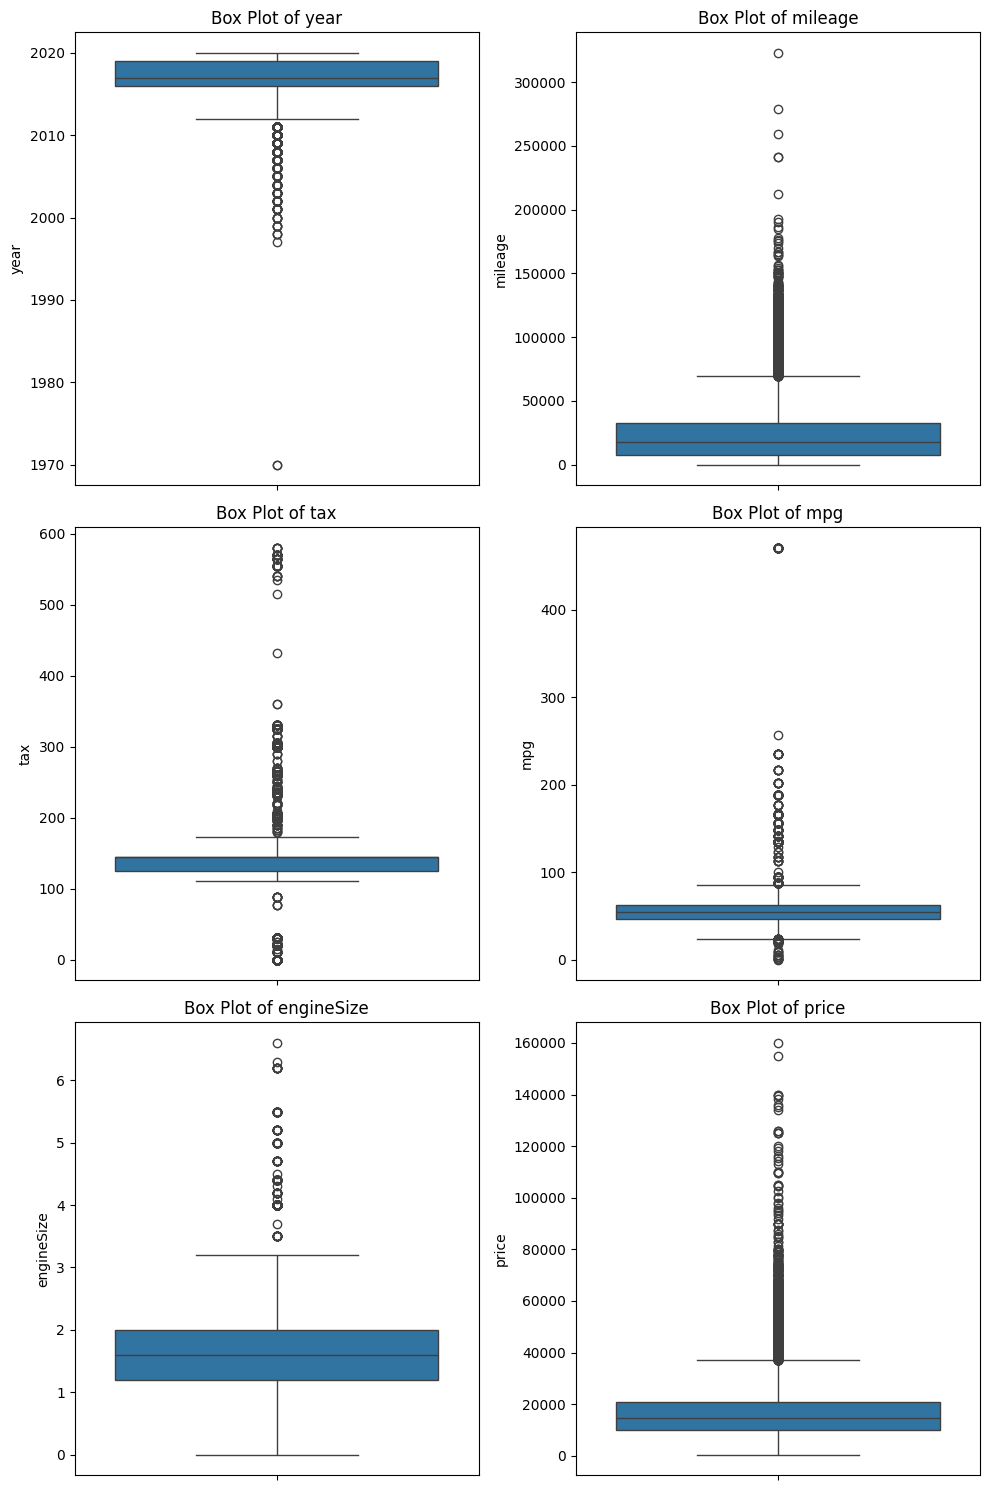

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Identify numerical columns
numerical_cols = train.select_dtypes(include=np.number).columns

# Determine the number of rows and columns for subplots
n_cols = 2 # Number of columns for subplots
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols # Calculate number of rows needed

# Plot box plots for each numerical column
plt.figure(figsize=(10, n_rows * 5)) # Adjust figure size for vertical plots
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=train[col]) # Change to y for vertical orientation
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col) # Change xlabel to ylabel

plt.tight_layout()
plt.show()

#이상치 처리(year)

In [17]:
# Filter rows where year is 1970
year_1970_rows = train[train['year'] == 1970]

# Display the filtered rows
print("'year' 값이 1970인 행:")
display(year_1970_rows)

'year' 값이 1970인 행:


,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
18945,vauxhall,Zafira,1970,Manual,37357.0,Petrol,200.0,42.2,1.4,10495
54861,merc,M Class,1970,Automatic,14000.0,Diesel,305.0,39.2,0.0,24999


In [18]:
# train 데이터프레임에서 year가 1970인 행 삭제
train = train[train['year'] != 1970].reset_index(drop=True)

# 삭제 확인 (선택 사항)
print("year 1970 행 삭제 후 train 데이터의 행 수:", len(train))
print("train 데이터에서 year 1970 확인:", train[train['year'] == 1970].shape[0])

year 1970 행 삭제 후 train 데이터의 행 수: 58625
train 데이터에서 year 1970 확인: 0


# 이상치 처리(mpg)

fuel type의 other을 채운 상태에서 도메인으로 bmw 이상치 채우기

In [19]:
# Filter rows where model is ' i3'
i3_model_rows_indices = train[train['model'] == ' i3'].index

# Change the 'mpg' value to 39 for these rows
train.loc[i3_model_rows_indices, 'mpg'] = 39

# Verify the changes (optional)
print("'model'이 'i3'인 행들의 'mpg' 값 변경 후:")
display(train[train['model'] == ' i3'])

'model'이 'i3'인 행들의 'mpg' 값 변경 후:


,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
1069,bmw,i3,2016,Automatic,20013.0,Hybrid,0.0,39.0,0.0,19875
2052,bmw,i3,2015,Automatic,79830.0,Hybrid,0.0,39.0,0.0,12500
2156,bmw,i3,2016,Automatic,43695.0,Hybrid,0.0,39.0,0.0,16482
4165,bmw,i3,2017,Automatic,24041.0,Hybrid,0.0,39.0,0.0,21495
4398,bmw,i3,2016,Automatic,25269.0,Hybrid,0.0,39.0,0.6,17100
6061,bmw,i3,2017,Automatic,41949.0,Hybrid,140.0,39.0,0.0,19998
8963,bmw,i3,2017,Automatic,26965.0,Hybrid,0.0,39.0,0.0,19980
9173,bmw,i3,2017,Automatic,29851.0,Hybrid,0.0,39.0,0.0,19895
10385,bmw,i3,2016,Automatic,9990.0,Electric,0.0,39.0,0.0,18999
11032,bmw,i3,2015,Automatic,9886.0,Hybrid,0.0,39.0,0.0,17481


In [20]:
# Define the outlier replacement rules
outlier_rules = [
    {'model': ' Passat', 'fuelType': 'Hybrid', 'threshold': 50, 'replace_value': 43.5},
    {'model': ' Golf', 'fuelType': 'Hybrid', 'threshold': 50, 'replace_value': 44.8},
    {'model': ' 5 Series', 'fuelType': 'Hybrid', 'threshold': 65, 'replace_value': 49.6},
    {'model': ' S Class', 'fuelType': 'Hybrid', 'threshold': 70, 'replace_value': 64.2},
    {'model': ' C Class', 'fuelType': 'Hybrid', 'threshold': 80, 'replace_value': 74.3},
    {'model': ' X5', 'fuelType': 'Hybrid', 'threshold': 85.6, 'replace_value': 85.6}
]

# Apply the replacement rules and track changes
changed_counts = {}
for rule in outlier_rules:
    model = rule['model']
    fuel_type = rule['fuelType']
    threshold = rule['threshold']
    replace_value = rule['replace_value']

    # Identify rows that match the rule and have mpg above the threshold
    condition = (train['model'] == model) & (train['fuelType'] == fuel_type) & (train['mpg'] > threshold)

    # Count rows to be changed
    num_changed = train.loc[condition].shape[0]
    changed_counts[f"{model} {fuel_type} (>{threshold})"] = num_changed

    # Replace the mpg values in the identified rows
    train.loc[condition, 'mpg'] = replace_value

# Display the number of rows changed for each rule
print("Number of rows changed by each outlier rule:")
display(changed_counts)

Number of rows changed by each outlier rule:


{' Passat Hybrid (>50)': 15,
 ' Golf Hybrid (>50)': 41,
 ' 5 Series Hybrid (>65)': 37,
 ' S Class Hybrid (>70)': 2,
 ' C Class Hybrid (>80)': 59,
 ' X5 Hybrid (>85.6)': 2}

In [21]:
# Identify rows where mpg was originally less than 11
rows_affected_by_clipping = train[train['mpg'] <= 11]

# Apply clipping to the 'mpg' column: replace values less than 11 with 11
train['mpg'] = train['mpg'].clip(lower=11)

# Display the rows that were affected to show the change in 'mpg'
print("Rows where 'mpg' was originally less than 11 (after clipping):")
display(train.loc[rows_affected_by_clipping.index])

# Verify the changes (optional) - check the minimum value of mpg
print("\nMinimum value of mpg after clipping:", train['mpg'].min())

Rows where 'mpg' was originally less than 11 (after clipping):


,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
204,hyundi,Ioniq,2020,Automatic,4152.0,Hybrid,135.0,11.0,1.6,23895
7563,bmw,X3,2020,Semi-Auto,2000.0,Hybrid,135.0,11.0,2.0,53995
11229,bmw,3 Series,2019,Semi-Auto,4953.0,Hybrid,135.0,11.0,2.0,33995
11844,toyota,C-HR,2018,Manual,16429.0,Petrol,145.0,11.0,1.2,16690
15334,toyota,Hilux,2020,Automatic,150.0,Diesel,260.0,11.0,2.4,36995
24179,toyota,Hilux,2020,Automatic,5000.0,Diesel,260.0,11.0,2.4,30500
26100,toyota,Hilux,2019,Automatic,10250.0,Diesel,260.0,11.0,2.4,27850
28365,bmw,3 Series,2019,Semi-Auto,4602.0,Hybrid,135.0,11.0,2.0,35230
32225,merc,A Class,2020,Semi-Auto,1000.0,Hybrid,135.0,11.0,1.3,31500
37503,bmw,X3,2020,Semi-Auto,1385.0,Hybrid,137.5,11.0,2.0,47000



Minimum value of mpg after clipping: 11.0


#이상치 처리(tax)

In [22]:
# 2018년 이후에 세금이 0인 행 필터링
tax_zero_after_2018 = train[
    (train['year'] >= 2018) &
    (train['tax'] == 0)
]

# 필터링된 행 보여주기
print("2018년 이후 데이터에서 세금이 0인 행:")
display(tax_zero_after_2018)

# 해당 행 개수 확인 (선택 사항)
print(f"\n2018년 이후 데이터에서 세금이 0인 행의 개수: {len(tax_zero_after_2018)}")

2018년 이후 데이터에서 세금이 0인 행:


,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
54292,vauxhall,Astra,2018,Manual,17863.0,Petrol,0.0,74.3,1.4,10998



2018년 이후 데이터에서 세금이 0인 행의 개수: 1


In [23]:
# Filter for rows where year is 2018 or later and tax is 0
rows_to_remove_tax_zero_after_2018 = train[
    (train['year'] >= 2018) &
    (train['tax'] == 0)
]

# Get the indices of these rows
indices_to_remove = rows_to_remove_tax_zero_after_2018.index

# Drop the identified rows from the train DataFrame
train = train.drop(indices_to_remove).reset_index(drop=True)

# Verify the deletion (optional)
print("Number of rows in train after removing tax 0 after 2018:", len(train))
print("Checking for tax 0 after 2018 in train:", train[(train['year'] >= 2018) & (train['tax'] == 0)].shape[0])

Number of rows in train after removing tax 0 after 2018: 58624
Checking for tax 0 after 2018 in train: 0


In [24]:
# 2018년 이전에 세금이 0인 행 필터링
tax_zero_before_2018 = train[
    (train['year'] < 2018) &
    (train['tax'] == 0)
]

# 필터링된 행 보여주기
print("2018년 이전에 세금이 0인 행:")
display(tax_zero_before_2018)

# 해당 행 개수 확인 (선택 사항)
print(f"\n2018년 이전에 세금이 0인 행의 개수: {len(tax_zero_before_2018)}")

2018년 이전에 세금이 0인 행:


,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
12,toyota,C-HR,2017,Automatic,13315.0,Hybrid,0.0,74.3,1.8,21388
14,ford,Fiesta,2015,Manual,28000.0,Diesel,0.0,88.3,1.5,6990
46,audi,A3,2015,Manual,68446.0,Diesel,0.0,74.3,1.6,8199
51,toyota,Aygo,2017,Manual,10262.0,Petrol,0.0,68.9,1.0,7695
54,ford,Fiesta,2017,Manual,15296.0,Petrol,0.0,65.7,1.0,10500
...,...,...,...,...,...,...,...,...,...,...
58563,ford,Fiesta,2017,Manual,24282.0,Petrol,0.0,65.7,1.0,8995
58565,toyota,Auris,2015,Automatic,34500.0,Hybrid,0.0,72.4,1.8,12795
58580,audi,A3,2016,Manual,59800.0,Diesel,0.0,74.3,1.6,10495
58590,bmw,3 Series,2016,Automatic,29789.0,Hybrid,0.0,134.5,2.0,19499



2018년 이전에 세금이 0인 행의 개수: 3598


#이상치 처리(engine size)

In [25]:
# engineSize가 0인 행 필터링
engine_size_zero_rows = train[train['engineSize'] == 0.0]

# engineSize가 0인 행 보여주기
print("'engineSize' 값이 0인 행:")
display(engine_size_zero_rows)

# engineSize가 0인 행들 중에서 fuelType이 Electric인 행 필터링
electric_zero_engine = engine_size_zero_rows[engine_size_zero_rows['fuelType'] == 'Electric']

# fuelType이 Electric인 engineSize 0 행 보여주기
print("\n'engineSize' 값이 0이고 'fuelType'이 Electric인 행:")
display(electric_zero_engine)

'engineSize' 값이 0인 행:


,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
525,hyundi,IX35,2015,Manual,26564.0,Petrol,200.0,41.5,0.0,9700
531,audi,Q2,2019,Manual,1076.0,Petrol,145.0,40.9,0.0,23888
696,audi,A3,2005,Manual,122000.0,Diesel,150.0,53.3,0.0,2495
865,audi,Q3,2020,Automatic,1500.0,Petrol,145.0,30.7,0.0,38888
983,merc,A Class,2016,Automatic,29712.0,Diesel,20.0,68.9,0.0,17500
...,...,...,...,...,...,...,...,...,...,...
55815,audi,TT,2017,Automatic,27607.0,Petrol,200.0,40.9,0.0,27000
57495,ford,Fiesta,2018,Manual,23000.0,Petrol,150.0,65.7,0.0,11325
57593,ford,Focus,2017,Manual,11000.0,Petrol,145.0,51.4,0.0,12975
58111,vauxhall,Insignia,2017,Manual,36595.0,Petrol,145.0,47.1,0.0,13000



'engineSize' 값이 0이고 'fuelType'이 Electric인 행:


,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
10385,bmw,i3,2016,Automatic,9990.0,Electric,0.0,39.0,0.0,18999
39663,bmw,i3,2017,Automatic,20321.0,Electric,135.0,39.0,0.0,18999


In [26]:
# Identify rows where engineSize is 0.0 and fuelType is not 'Electric'
condition_to_impute = (train['engineSize'] == 0.0) & (train['fuelType'] != 'Electric')
rows_to_impute_indices = train.loc[condition_to_impute].index

# Calculate the mode of 'engineSize' for each year and model group, excluding engineSize 0.0 values from the calculation
# We calculate mode from rows where engineSize is NOT 0
engine_size_mode_by_year_model = (
    train[train['engineSize'] != 0.0]
    .groupby(['year', 'model'])['engineSize']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'engineSize': 'suggested_engineSize'})
)

# Merge suggested engine size back to the original train DataFrame
# This merge will bring the suggested_engineSize for rows where year and model match
train = train.merge(engine_size_mode_by_year_model, on=['year', 'model'], how='left')

# Impute engineSize 0.0 values based on the condition_to_impute using the suggested_engineSize
# Ensure suggested_engineSize is not None before imputing
for index in rows_to_impute_indices:
    suggested_value = train.loc[index, 'suggested_engineSize']
    if pd.notnull(suggested_value):
        train.loc[index, 'engineSize'] = suggested_value

# Drop the temporary suggested_engineSize column
train = train.drop('suggested_engineSize', axis=1)

# Verify the changes (optional)
print("'engineSize'가 0인 행들 중 전기차 제외하고 대체 후 'engineSize' 분포:")
display(train[condition_to_impute]['engineSize'].value_counts(dropna=False))

print("\n남아있는 'engineSize' 0 값 개수:")
display(train[train['engineSize'] == 0.0].shape[0])

'engineSize'가 0인 행들 중 전기차 제외하고 대체 후 'engineSize' 분포:


,count
engineSize,
2.0,39
1.0,33
0.6,23
1.4,16
1.5,15
1.2,9
0.0,6
1.6,6
1.7,3



남아있는 'engineSize' 0 값 개수:


8

In [27]:
# Identify rows to be removed: engineSize is 0.0 AND fuelType is NOT 'Electric'
rows_to_remove = train[
    (train['engineSize'] == 0.0) &
    (train['fuelType'] != 'Electric')
]

# Get the indices of these rows
indices_to_remove = rows_to_remove.index

# Drop the identified rows from the train DataFrame
train = train.drop(indices_to_remove).reset_index(drop=True)

# Verify the deletion (optional)
print("Number of rows in train after removing non-electric engineSize 0.0 outliers:", len(train))
print("Checking for non-electric engineSize 0.0 rows:", train[(train['engineSize'] == 0.0) & (train['fuelType'] != 'Electric')].shape[0])
print("Checking for electric engineSize 0.0 rows:", train[(train['engineSize'] == 0.0) & (train['fuelType'] == 'Electric')].shape[0])

Number of rows in train after removing non-electric engineSize 0.0 outliers: 58618
Checking for non-electric engineSize 0.0 rows: 0
Checking for electric engineSize 0.0 rows: 2


In [28]:
remaining_zero_engine_size_rows = train[train['engineSize'] == 0.0]
display(remaining_zero_engine_size_rows)

,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
10384,bmw,i3,2016,Automatic,9990.0,Electric,0.0,39.0,0.0,18999
39657,bmw,i3,2017,Automatic,20321.0,Electric,135.0,39.0,0.0,18999


#이상치 처리(mileage)

#이상치 처리(price)

KAROQ(91874->31990), MOKKA(52489->22499)

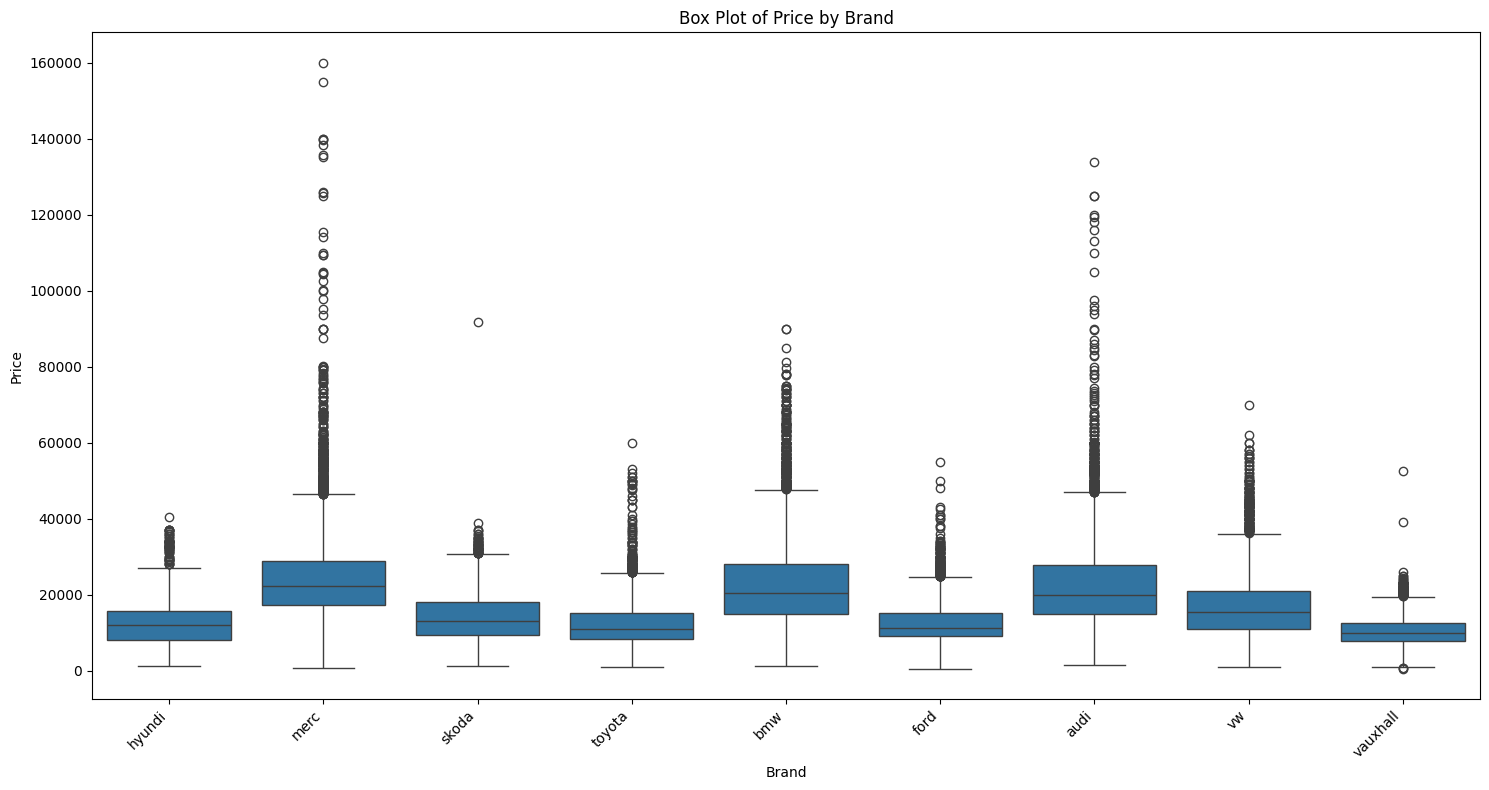

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot of price by brand
plt.figure(figsize=(15, 8)) # Adjust figure size for better readability
sns.boxplot(data=train, x='brand', y='price')
plt.title('Box Plot of Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

In [30]:
# Define the outlier treatment rules for price
price_outlier_rules = [
    {'brand': 'skoda', 'model': ' Karoq'}, # Added leading space
    {'brand': 'vauxhall', 'model': ' Mokka'}, # Added leading space
    {'brand': 'vauxhall', 'model': ' Insignia'} # Added rule for Vauxhall Insignia
]

# Apply the outlier treatment for each rule
for rule in price_outlier_rules:
    brand = rule['brand']
    model = rule['model']

    # Filter data for the specific brand and model
    model_data = train[(train['brand'] == brand) & (train['model'] == model)].copy()

    # Sort by price in descending order
    sorted_model_data = model_data.sort_values(by='price', ascending=False)

    # Check if there are at least two unique prices to perform the replacement
    unique_prices = sorted_model_data['price'].unique()

    if len(unique_prices) >= 2:
        highest_price = unique_prices[0]
        second_highest_price = unique_prices[1]

        # Identify the index of the row(s) with the highest price in the original train DataFrame
        indices_to_replace = train[(train['brand'] == brand) & (train['model'] == model) & (train['price'] == highest_price)].index

        # Replace the highest price with the second highest price in the original train DataFrame
        train.loc[indices_to_replace, 'price'] = second_highest_price

        print(f"{brand} {model}: Highest price ({highest_price}) replaced with second highest price ({second_highest_price}).")
    elif len(unique_prices) == 1:
         print(f"{brand} {model}: Only one unique price found. No replacement needed for highest price.")
    else:
        print(f"{brand} {model}: No price data found.")


# Verify the changes (optional) - You can display rows with the second highest price for these models if needed
# Example verification for Skoda Karoq (optional)
# print("\nChecking prices for Skoda Karoq after outlier treatment:")
# display(train[(train['brand'] == 'skoda') & (train['model'] == ' Karoq')].sort_values(by='price', ascending=False))

skoda  Karoq: Highest price (91874) replaced with second highest price (31990).
vauxhall  Mokka: Highest price (52489) replaced with second highest price (22499).
vauxhall  Insignia: Highest price (39000) replaced with second highest price (25999).


# 중복되는 행 제거

In [31]:
# 중복되는 행 확인 및 제거
initial_rows = len(train)

# 중복되는 행 식별 (첫 번째 발생 행 제외)
duplicate_rows = train[train.duplicated(keep=False)]

if not duplicate_rows.empty:
    print("### 중복되는 행(전체 열 기준):")
    display(duplicate_rows.sort_values(by=list(train.columns)))
    print(f"총 {len(duplicate_rows)}개의 중복 행이 발견되었습니다.\n")

    # 중복되는 행 제거 (첫 번째 발생 행은 남기고 나머지 제거)
    train = train.drop_duplicates(keep='first').reset_index(drop=True)
    removed_rows = initial_rows - len(train)
    print(f"중복되는 행 {removed_rows}개 삭제 후 train 데이터의 행 수: {len(train)}")
else:
    print("### 현재 train 데이터프레임에 중복되는 행이 없습니다.")
    removed_rows = 0

# 최종 확인
print("train 데이터에서 중복되는 행 확인 (삭제 후):", train[train.duplicated()].shape[0])

### 중복되는 행(전체 열 기준):


,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
24893,ford,Fiesta,2013,Manual,40950.0,Petrol,0.0,65.7,1.0,6100
31227,ford,Fiesta,2013,Manual,40950.0,Petrol,0.0,65.7,1.0,6100
3483,merc,B Class,2019,Semi-Auto,8623.0,Diesel,145.0,54.3,2.0,26999
27026,merc,B Class,2019,Semi-Auto,8623.0,Diesel,145.0,54.3,2.0,26999
31923,merc,E Class,2015,Semi-Auto,30000.0,Diesel,125.0,55.4,2.1,15999
56787,merc,E Class,2015,Semi-Auto,30000.0,Diesel,125.0,55.4,2.1,15999
24385,skoda,Kodiaq,2019,Automatic,5500.0,Diesel,145.0,39.2,2.0,27495
35685,skoda,Kodiaq,2019,Automatic,5500.0,Diesel,145.0,39.2,2.0,27495


총 8개의 중복 행이 발견되었습니다.

중복되는 행 4개 삭제 후 train 데이터의 행 수: 58614
train 데이터에서 중복되는 행 확인 (삭제 후): 0


# 인코딩

In [32]:
# 인코딩을 진행할 범주형 변수 목록
categorical_cols = ['brand', 'model', 'transmission', 'fuelType']

print("Train 데이터와 Test 데이터의 범주형 변수 클래스 비교:")

# 각 범주형 변수에 대해 클래스 비교
for feature in categorical_cols:
    # train set에 있는 클래스 확인
    train_classes = set(train[feature])

    # test set에 있는 클래스 확인
    test_classes = set(test[feature])

    # test set에만 있는 클래스 확인
    only_in_test = test_classes - train_classes

    # train set에만 있는 클래스 확인 (선택 사항, 주로 test에만 있는 것을 확인)
    # only_in_train = train_classes - test_classes

    if only_in_test:
        print(f"- '{feature}' 변수에 Test 데이터에만 있는 클래스:")
        print(only_in_test)
    # if only_in_train: # train에만 있는 클래스를 보고 싶을 경우 주석 해제
    #     print(f"- '{feature}' 변수에 Train 데이터에만 있는 클래스:")
    #     print(only_in_train)

    if not only_in_test: # and not only_in_train: # 둘 다 비어있으면 같다고 표시
        print(f"- '{feature}' 변수의 Train/Test 클래스가 일치하거나, Test에만 있는 클래스가 없습니다.")

print("\n참고: OneHotEncoder의 handle_unknown='ignore' 옵션은 Test 데이터에 Train 데이터에 없는 클래스가 있을 경우 해당 클래스를 무시하고 인코딩합니다. 이는 오류를 방지하지만, 해당 클래스의 정보가 손실될 수 있습니다.")

Train 데이터와 Test 데이터의 범주형 변수 클래스 비교:
- 'brand' 변수의 Train/Test 클래스가 일치하거나, Test에만 있는 클래스가 없습니다.
- 'model' 변수에 Test 데이터에만 있는 클래스:
{' Kadjar', ' Veloster', ' Escort', '200', '220', ' Ampera', ' Ranger', ' A2', '180', '230'}
- 'transmission' 변수에 Test 데이터에만 있는 클래스:
{'Other'}
- 'fuelType' 변수에 Test 데이터에만 있는 클래스:
{'Other'}

참고: OneHotEncoder의 handle_unknown='ignore' 옵션은 Test 데이터에 Train 데이터에 없는 클래스가 있을 경우 해당 클래스를 무시하고 인코딩합니다. 이는 오류를 방지하지만, 해당 클래스의 정보가 손실될 수 있습니다.


In [33]:
brand_model = pd.read_csv(data_path + '/' + data_name[2])

In [34]:
# 범주형 변수의 class가 정확히 주어지지 않을 경우는 다음과 같이 사용
object_features = ['model', 'brand','transmission', 'fuelType']

for feature in object_features:
    # train set에 있는 클래스 확인
    train_classes = set(train[feature])

    # test set에만 있는 클래스 확인
    test_classes = set(test[feature]) - train_classes

    if len(test_classes) != 0: # train에서의 class와 test에서의 class가 다른 경우
        test.loc[test[feature].isin(test_classes), feature] = 'Unknown' # test에만 있는 class를 unknown으로 치환
        le = LabelEncoder()
        le = le.fit(train[feature])
        train[feature] = le.transform(train[feature])
        le.classes_ = np.append(le.classes_, 'Unknown') # label encoder의 classes에 Unknown 추가 후 test set을 transform
        test[feature] = le.transform(test[feature])
        print(f'{feature} 컬럼은 test set에만 있는 클래스 {test_classes}를 포함하고 있습니다.')

    else: # train에서의 class와 test에서의 class가 같은 경우
        le = LabelEncoder()
        le = le.fit(train[feature])
        train[feature] = le.transform(train[feature])
        test[feature] = le.transform(test[feature])

model 컬럼은 test set에만 있는 클래스 {' Kadjar', ' Veloster', ' Escort', '200', '220', ' Ampera', ' Ranger', ' A2', '180', '230'}를 포함하고 있습니다.
transmission 컬럼은 test set에만 있는 클래스 {'Other'}를 포함하고 있습니다.
fuelType 컬럼은 test set에만 있는 클래스 {'Other'}를 포함하고 있습니다.


In [35]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 특징(X)과 타겟 변수(y) 분리
# 타겟 변수는 'price'입니다.
X = train.drop('price', axis=1)
y = train['price']

# train 데이터를 학습 세트와 검증 세트로 분할 (80:20 비율)
# stratify=y를 사용하여 타겟 변수의 분포를 유지할 수 있지만, 회귀 문제이므로 일반적으로 사용하지 않습니다.
# random_state를 고정하여 분할 결과 재현성을 확보합니다.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 분할된 데이터셋의 형태 확인
print("학습 세트 (X_train, y_train) 형태:", X_train.shape, y_train.shape)
print("검증 세트 (X_val, y_val) 형태:", X_val.shape, y_val.shape)

학습 세트 (X_train, y_train) 형태: (46891, 9) (46891,)
검증 세트 (X_val, y_val) 형태: (11723, 9) (11723,)


#모델링(LIGHTGBM)

In [36]:
!pip install lightgbm

In [37]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# X_train, X_val, y_train, y_val은 이전 셀에서 이미 분할되었습니다.

# LightGBM에 사용할 범주형 특성 식별
# Label Encoding이 이미 적용되어 있으므로, LightGBM 모델에 이 컬럼들이 범주형임을 알려주어야 합니다.
# LabelEncoder를 사용하여 변환된 컬럼들이므로, 이들은 int 타입이지만 LightGBM에서는 범주형으로 처리되어야 합니다.
# 따라서, 원래 범주형이었던 컬럼 이름을 직접 지정합니다.
categorical_features_names = ['brand', 'model','transmission', 'fuelType'] # These were the original object_features

# LightGBM은 정수 인코딩된 범주형 변수를 직접 처리할 수 있습니다.
# LightGBM 모델 생성 및 학습
# n_estimators: 부스팅 라운드 수
# learning_rate: 학습률
# num_leaves: 트리의 최대 잎 노드 수
# objective: 회귀 문제이므로 'regression' 또는 'rmse' 사용
# random_state: 재현성을 위한 시드 고정
# categorical_feature: 범주형으로 처리할 특성의 이름 리스트 또는 인덱스

lgbm_model = lgb.LGBMRegressor(objective='rmse',
                              n_estimators=2000,
                              learning_rate=0.05,
                              num_leaves=31, # 기본값 사용 또는 튜닝
                              random_state=42,
                              n_jobs=-1) # 모든 코어 사용

print("\nLightGBM 회귀 모델 학습 시작...")

lgbm_model.fit(X_train, y_train,
               eval_set=[(X_val, y_val)],
               eval_metric='rmse',
               callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=True)], # 검증 세트 성능 향상 없을 시 100회 후 조기 종료
               categorical_feature=categorical_features_names) # Pass the explicit list of categorical feature names

print("\nLightGBM 회귀 모델 학습 완료.")

# 검증 세트에 대한 예측 수행
y_pred_val_lgbm = lgbm_model.predict(X_val)

# R^2 및 RMSE 값 계산
r2_val_lgbm = r2_score(y_val, y_pred_val_lgbm)
rmse_val_lgbm = np.sqrt(mean_squared_error(y_val, y_pred_val_lgbm))

print(f"\nValidation R^2 Score (LightGBM): {r2_val_lgbm:.4f}")
print(f"Validation RMSE (LightGBM): {rmse_val_lgbm:.4f}")



LightGBM 회귀 모델 학습 시작...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031700 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 712
[LightGBM] [Info] Number of data points in the train set: 46891, number of used features: 9
[LightGBM] [Info] Start training from score 16799.295942
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1581]	valid_0's rmse: 1831.59

LightGBM 회귀 모델 학습 완료.

Validation R^2 Score (LightGBM): 0.9658
Validation RMSE (LightGBM): 1831.5936


#모델링(CATBOOST)

In [38]:
!pip install catboost
from catboost import CatBoostRegressor
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split # train_test_split import 확인
from sklearn.metrics import r2_score # R^2 계산을 위해 r2_score import

# 특징(X_train, X_val)과 타겟 변수(y_train, y_val)는 이미 이전 셀(rv1AGpg_r_pV)에서 분할됨
# 분할된 X_train, X_val, y_train, y_val 변수를 사용합니다.

# X_train에서 범주형 특성 컬럼 이름 및 인덱스 식별
# X_train 데이터프레임의 컬럼 데이터 타입을 확인하여 범주형 특성 식별
# object 또는 category dtype인 컬럼을 범주형으로 간주합니다.
categorical_features_names_identified = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# 식별된 범주형 특성의 정수형 인덱스 찾기 (X_train 데이터프레임 기준)
categorical_features_indices_identified = [X_train.columns.get_loc(col) for col in categorical_features_names_identified]

# X_train에 남아있는 object 타입 컬럼이 있다면 category로 변환 시도 (CatBoost가 선호)
for col in categorical_features_names_identified:
    if col in X_train.columns and X_train[col].dtype == 'object': # 컬럼 존재 여부 확인 추가
        X_train[col] = X_train[col].astype('category')
    if col in X_val.columns and X_val[col].dtype == 'object': # 컬럼 존재 여부 확인 추가
         X_val[col] = X_val[col].astype('category')


print(f"식별된 범주형 특성 컬럼: {categorical_features_names_identified}")
print(f"식별된 범주형 특성 인덱스: {categorical_features_indices_identified}")


# CatBoost Regressor 모델 생성 및 학습
# random_state를 고정하여 결과 재현성을 확보합니다.
# verbose=0으로 설정하여 학습 과정 출력 생략 (선택 사항)
# early_stopping_rounds를 사용하여 검증 세트로 조기 종료 설정 (과적합 방지)
catboost_model = CatBoostRegressor(iterations=2000, # 충분히 큰 반복 횟수 설정
                                   learning_rate=0.05, # 학습률 조정
                                   depth=7, # 트리의 깊이 조정
                                   loss_function='RMSE', # 회귀 문제이므로 RMSE 사용
                                   # metrics='R2', # CatBoost에 R2 메트릭스를 추가할 수도 있습니다.
                                   random_state=42,
                                   verbose=200, # 200 iteration마다 출력
                                   cat_features=categorical_features_indices_identified, # 식별된 범주형 특성 인덱스 지정
                                  )

print("\nCatBoost 회귀 모델 학습 시작...")
# 모델 학습
# 검증 세트(X_val, y_val)를 사용하여 조기 종료 기준 및 성능 모니터링
# early_stopping_rounds를 명시적으로 지정하여 fit 메서드 인자가 우선하도록 함
catboost_model.fit(X_train, y_train,
                   eval_set=(X_val, y_val), # 검증 세트 지정
                   early_stopping_rounds=100, # 검증 세트 성능 향상 없을 시 100회 후 조기 종료
                   verbose=200 # fit 메서드 인자가 우선
                  )

print("\nCatBoost 회귀 모델 학습 완료.")

# 학습된 최적 반복 횟수 확인 (조기 종료 발생 시)
print(f"Optimal iteration (best iteration): {catboost_model.get_best_iteration()}")
print(f"Best validation score (RMSE): {catboost_model.get_best_score()['validation']['RMSE']}")

# 검증 세트에 대한 예측 수행
y_pred_val = catboost_model.predict(X_val)

# R^2 값 계산
r2_val = r2_score(y_val, y_pred_val)

print(f"\nValidation R^2 Score: {r2_val}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.9 MB/s eta 0:00:00
식별된 범주형 특성 컬럼: []
식별된 범주형 특성 인덱스: []

CatBoost 회귀 모델 학습 시작...
0:	learn: 9492.7766028	test: 9543.7184013	best: 9543.7184013 (0)	total: 94ms	remaining: 3m 7s
200:	learn: 2515.2093508	test: 2634.7991193	best: 2634.7991193 (200)	total: 5.9s	remaining: 52.8s
400:	learn: 2123.4816835	test: 2255.9750871	best: 2255.9750871 (400)	total: 12.8s	remaining: 50.9s
600:	learn: 1952.7238372	test: 2108.4293998	best: 2108.4293998 (600)	total: 17.7s	remaining: 41.3s
800:	learn: 1851.0985332	test: 2032.3574372	best: 2032.3574372 (800)	total: 20s	remaining: 30s
1000:	learn: 1775.6105902	test: 1983.2602880	best: 1983.2602880 (1000)	total: 21.9s	remaining: 21.9s
1200:	learn: 1717.9520457	test: 1951.1461748	best: 1951.1461748 (1200)	total: 26s	remaining: 17.3s
1400:	learn: 1674.4552669	test: 1929.1134511	best: 1929.1134511 (1400)	total: 28.3s	remaining: 12.1s
1600:	learn: 1637.7730161	test: 1909.6112962	best: 1909.6112962 (1600)	tot

In [39]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD # SVD import
import pandas as pd
import numpy as np

# 범주형 변수 목록
categorical_cols = ['brand', 'model', 'transmission', 'fuelType']

# ColumnTransformer를 사용하여 범주형 변수에 OneHotEncoder 적용
# remainder='passthrough'는 수치형 변수를 그대로 유지
# handle_unknown='ignore'는 Test 데이터에 Train 데이터에 없는 클래스가 있을 경우 무시하도록 설정
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)],
    remainder='passthrough' # Keep numerical columns
)

# train 데이터에 전처리기 적용 (원-핫 인코딩)
# 출력은 OneHotEncoder가 희소 행렬을 생성하면 희소 행렬이 될 수 있음
# fit과 transform을 train 데이터에만 수행
train_encoded = preprocessor.fit_transform(train)

# 인코딩된 결과를 DataFrame으로 변환 (밀집 형태로 변환)
# Get feature names after preprocessing (fitted on train)
if hasattr(preprocessor, 'get_feature_names_out'):
    processed_feature_names = preprocessor.get_feature_names_out()
else:
    # Manual way for older versions
    cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
    # Get numerical columns that were passed through from the original train columns
    numerical_passthrough_cols_train = [col for col in train.columns if col in train.select_dtypes(include=np.number).columns.tolist() and col not in categorical_cols]
    # Ensure 'price' is included in feature names if it was in original numerical_cols
    if 'price' in train.columns and 'price' not in numerical_passthrough_cols_train:
        numerical_passthrough_cols_train.append('price') # Add price if it's numerical and not in categorical

    processed_feature_names = np.concatenate([cat_feature_names, numerical_passthrough_cols_train])


train_processed_ohe = pd.DataFrame(train_encoded.toarray(), columns=processed_feature_names, index=train.index)

# --- NaN 값 확인 및 처리 ---
# TruncatedSVD는 NaN 값을 허용하지 않으므로, 남아있는 NaN을 0으로 채웁니다.
# 이전에 모든 결측치를 처리했다고 판단했지만, 혹시 모를 경우를 대비한 방어 코드입니다.
if train_processed_ohe.isnull().sum().sum() > 0:
    print(f"경고: SVD 적용 전 {train_processed_ohe.isnull().sum().sum()}개의 NaN 값이 발견되었습니다. 이 값들을 0으로 채웁니다.")
    train_processed_ohe.fillna(0, inplace=True)


# --- SVD 적용 ---
# SVD를 위한 컴포넌트 개수 선택 (예: n_components=50)
# 컴포넌트 개수는 인코딩 후 특성 개수보다 작거나 같아야 함
# 적절한 개수로 시작하며, 필요에 따라 조정 가능
n_components_svd = 50 # 예시 컴포넌트 개수

# SVD 모델 생성 및 train 데이터에 fit_transform 적용
# SVD는 수치형 데이터에 적용되므로, 원-핫 인코딩된 결과에 바로 적용합니다.
svd = TruncatedSVD(n_components=n_components_svd, random_state=0)
train_svd_transformed = svd.fit_transform(train_processed_ohe)

# SVD 변환 결과를 DataFrame으로 변환
train_svd_df = pd.DataFrame(train_svd_transformed, index=train_processed_ohe.index,
                            columns=[f'svd_{i+1}' for i in range(n_components_svd)])


print("Train 데이터: 원-핫 인코딩 적용 후 데이터 형태:")
print(train_processed_ohe.shape)
display(train_processed_ohe.head())

print("\nTrain 데이터: 원-핫 인코딩 및 SVD 적용 후 데이터 형태:")
print(train_svd_df.shape)
display(train_svd_df.head())


# 테스트 데이터는 인코딩하지 않음 (사용자 요청에 따름)
# print("\nTest 데이터: 원-핫 인코딩 적용 후 데이터 형태:")
# print(test_processed_ohe.shape)
# display(test_processed_ohe.head())

Train 데이터: 원-핫 인코딩 적용 후 데이터 형태:
(58614, 207)


,cat__brand_0,cat__brand_1,cat__brand_2,cat__brand_3,cat__brand_4,cat__brand_5,cat__brand_6,cat__brand_7,cat__brand_8,cat__model_0,...,cat__fuelType_0,cat__fuelType_1,cat__fuelType_2,cat__fuelType_3,remainder__year,remainder__mileage,remainder__tax,remainder__mpg,remainder__engineSize,remainder__price
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,2015.0,18078.0,20.0,67.3,1.6,8995.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,2018.0,4350.0,145.0,68.9,2.1,19499.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,2019.0,9373.0,145.0,67.3,1.6,14395.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,2011.0,74488.0,200.0,41.5,1.6,5899.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,2019.0,608.0,145.0,42.2,2.0,26949.0



Train 데이터: 원-핫 인코딩 및 SVD 적용 후 데이터 형태:
(58614, 50)


,svd_1,svd_2,svd_3,svd_4,svd_5,svd_6,svd_7,svd_8,svd_9,svd_10,...,svd_41,svd_42,svd_43,svd_44,svd_45,svd_46,svd_47,svd_48,svd_49,svd_50
0,20219.595074,1452.019852,916.969378,-89.693999,0.828254,1.354673,-0.561375,-0.657462,0.168344,0.169666,...,0.025997,-0.044154,-0.012933,0.056385,0.031686,-0.006587,0.019280,-0.065005,-0.140071,0.186150
1,11560.916480,16408.805364,572.247962,12.196213,17.396071,0.998603,-0.483704,-0.580446,0.125973,-0.005464,...,0.011945,-0.038196,-0.013993,-0.006501,-0.027432,-0.006192,-0.011886,0.009817,0.018220,0.002549
2,14248.047684,9774.525066,788.774288,22.479074,14.136416,0.553169,0.605088,-0.064143,-0.262716,-0.132429,...,0.102697,-0.112017,-0.008091,-0.005082,0.005719,-0.005649,0.003845,-0.000072,-0.005093,0.003855
3,71097.256600,-23073.434743,-359.523812,116.430984,-9.569343,-0.694133,-0.160082,0.006539,-0.152944,-0.003089,...,0.057453,-0.024109,0.016171,-0.015191,-0.062923,-0.118689,0.136889,-0.057537,0.094873,-0.117315
4,10951.661867,24713.396799,162.816620,1.066858,-6.908518,-0.033219,-0.860902,-0.613943,0.238697,-0.021282,...,-0.001233,-0.003611,0.007226,-0.001101,-0.006121,0.010226,-0.010392,0.004533,0.007743,-0.009122


#모델링(XGBOOST)

In [40]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 특징(X)과 타겟 변수(y) 분리
# 타겟 변수는 'price'입니다.
X = train.drop('price', axis=1)
y = train['price']

# train 데이터를 학습 세트와 검증 세트로 분할 (80:20 비율)
# stratify=y를 사용하여 타겟 변수의 분포를 유지할 수 있지만, 회귀 문제이므로 일반적으로 사용하지 않습니다.
# random_state를 고정하여 분할 결과 재현성을 확보합니다.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 분할된 데이터셋의 형태 확인
print("학습 세트 (X_train, y_train) 형태:", X_train.shape, y_train.shape)
print("검증 세트 (X_val, y_val) 형태:", X_val.shape, y_val.shape)

학습 세트 (X_train, y_train) 형태: (46891, 9) (46891,)
검증 세트 (X_val, y_val) 형태: (11723, 9) (11723,)


In [41]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np # np.sqrt를 위해 numpy를 임포트합니다.

# X_train과 X_val의 'brand', 'model', 'transmission', 'fuelType' 컬럼은 이전에 Label Encoding되어 정수형입니다.

# XGBoost Regressor 모델 초기화
xgbr = xgb.XGBRegressor(objective='reg:squarederror', # 회귀 문제에 적합한 목적 함수
                        n_estimators=1000,           # 부스팅 라운드 수
                        learning_rate=0.05,          # 학습률
                        max_depth=7,                 # 트리의 최대 깊이
                        subsample=0.8,               # 각 부스팅 라운드에서 사용될 데이터의 샘플링 비율
                        colsample_bytree=0.8,        # 각 부스팅 라운드에서 사용될 피처의 샘플링 비율
                        random_state=42,             # 재현성을 위한 난수 시드
                        n_jobs=-1,                   # 병렬 처리할 CPU 코어 수 (-1은 모든 코어 사용)
                        enable_categorical=True,     # Label Encoding된 범주형 특성 처리를 활성화 (XGBoost 1.6+)
                        tree_method='hist'           # 히스토그램 기반 트리 생성으로 범주형 변수 처리 효율적
                       )

print("XGBoost 모델 학습 시작...")
# 모델 학습
# X_train과 y_train은 Label Encoding된 데이터로, enable_categorical=True 설정으로 XGBoost가 이를 인식합니다.
xgbr.fit(X_train, y_train)
print("XGBoost 모델 학습 완료.")

# 검증 세트로 예측 수행
y_pred_val = xgbr.predict(X_val)

# 모델 성능 평가
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2_val = r2_score(y_val, y_pred_val)

print(f"\nXGBoost 모델 검증 세트 RMSE: {rmse_val:.4f}")
print(f"XGBoost 모델 검증 세트 R2 Score: {r2_val:.4f}")

XGBoost 모델 학습 시작...
XGBoost 모델 학습 완료.

XGBoost 모델 검증 세트 RMSE: 1836.9258
XGBoost 모델 검증 세트 R2 Score: 0.9656


In [42]:
sample_submission = pd.read_csv(data_path + '/' + data_name[4])

In [43]:
# test 데이터에서 'id' 컬럼을 제거하여 모델 예측에 사용할 피처셋 생성
# 모델은 'id' 컬럼 없이 학습되었으므로, 예측 시에도 동일하게 처리해야 합니다.
X_test = test.drop('id', axis=1)

# XGBoost 모델을 사용하여 test 데이터에 대한 price 예측
print("Test 데이터 price 예측 시작...")
y_pred_test = xgbr.predict(X_test)
print("Test 데이터 price 예측 완료.")

# 예측 결과를 sample_submission DataFrame의 'price' 컬럼에 할당
sample_submission['price'] = y_pred_test

# 예측 결과의 음수 값을 0으로 처리 (가격은 음수가 될 수 없음)
sample_submission['price'] = sample_submission['price'].apply(lambda x: max(0, x))

# sample_submission DataFrame의 상위 5개 행을 출력하여 확인
print("\nSample Submission 예측 결과 (상위 5개):")
display(sample_submission.head())

# 결과를 CSV 파일로 저장
submission_file_path = data_path + '/xgboost_submission.csv'
sample_submission.to_csv(submission_file_path, index=False)
print(f"\n예측 결과가 '{submission_file_path}' 에 성공적으로 저장되었습니다.")

Test 데이터 price 예측 시작...
Test 데이터 price 예측 완료.

Sample Submission 예측 결과 (상위 5개):


,id,price
0,69940,21290.808594
1,44315,15274.655273
2,41540,11590.668945
3,18443,17156.181641
4,52142,19948.031250



예측 결과가 '/content/drive/My Drive/Colab Notebooks/IBA_REG/xgboost_submission.csv' 에 성공적으로 저장되었습니다.
